# Data Selection and Finaly Project Planning Lab
---

**Project Name:** Allocating Scarce Medicaid Coverage: A Counterfactual Comparison of Lottery, Need-Based, and Learned Targeting in the Oregon Health Insurance Experiment

**Author:** Chayce Reed

**Date:** 10/03/26

<br>

### Data Source
---

**Data Source:** Oregon Health Insurance Experiment (OHIE) Public Use Dataset

**Data Access:** https://www.nber.org/research/data/oregon-health-insurance-experiment-data (Free registration, if prompted)

**Data Description:** "In 2008, a group of uninsured low-income adults in Oregon was selected by lottery to be given the chance
to apply for Medicaid. This lottery provides a unique opportunity to gauge the effects of expanding access
to public health insurance on the health care use, financial strain, and health of low-income adults using a
randomized controlled design. The Oregon Health Insurance Experiment followed and compared those
selected in the lottery (treatments) with those not selected (controls)."


**Data Files:** The dataset includes six separate datasets from the OHIE that have been made pubiicly available. For this project, the following datasets will be used: Descriptive Variables (oregonhie_descriptive_vars.dta), State Program Variables (oregonhie_stateprograms_vars.dta), and Tweleve Month Mail Survey (oregonhie_survey12m_vars.dta).


**Data Selection:** The OHIE dataset was selected for this project because it provides a unique opportunity to analyze the effects of Medicaid coverage on low-income adults in Oregon. The experiment's randomized "lottery" design allows for the comparison between those who were selected for Medicaid coverage and those who were not, making it a useful dataset for studying the impact of health insurance on various outcomes. This dataset also lines up directly with my research interests and goals. I am applying to PhD programs to study causal inference for health services, policy, and equity research, across two key areas: how health policy and health care delivery systems shape access for marginalized populations, and how automated decision-making produces and entrenches disparities in health care. This dataset and project fits squarely into the former, and will allow me to investigate how coverage decisions affect low-income, uninsured populations and how those decisions could be made more equitably. The data includes characteristics recorded before the lottery, which makes it possible to estimate the causal effect of a coverage offer, test whether the effect differs across subgroups, and simulate whether an alternative allocation rule (e.g., need-based, learned-targeting) would have prevented more medical debt than the lottery. This combination of causal inference, policy simulation, and equity analysis is the kind of work I am hoping to develop my future PhD research agenda around, which makes it a very exciting dataset and project to work on.


**Binary Classification:** Yes. The target whether the respondent owes money for medical expenses at 12 months (binary: 1 = yes, 0 = no).

**Observation Count:** 23,741 respondents to the 12-month survey, out of 74,922 total people on the original lottery list.

**Predictor Variable Count:** 15 predictor variables measured before the lottery, including: age, sex, english-language preference, self-signup, phone number provided, PO box addressed used, metro-area zip, signup week, first-day signup, last-day signup, prior SNAP participant, prior TANF participant, household SNAP dollars, household TANF dollars, and any-state program indicator.

**Acknowledgements:** The project uses the public-use data from the Oregon Health Insurance Experiment, made available by the National Bureau of Economic Research (NBER).

Finkelstein, Amy. Oregon Health Insurance Experiment Public Use Data, 2013. Available at https://www.nber.org/research/data/oregon-health-insurance-experiment-data.

<br>

### Data Quality Assessment
---

**Anticipated Preprocssing Steps:**

- Merge the three datasets (descriptive, state program, and 12-month survey) into a single dataset for analysis.
- Convert columns that loaded as an object datat type to the appropriate data type (e.g., categorical, numeric).
- Rename variables to shorter, more interpretable names.
- Restrict dataset to only include respondents who completed the 12-month survey.
- Derive age from birth year and survey date.
- Review data dictionary to verify if missing SNAP/TANF benefit dollar amounts should be set to 0 or treated as missing.
- Standardize continuous predictors (if appropriate, pending modeling approach, TBD).
- Apply survey weights (per the data dictionary and documentation) to ensure that the analysis is properly representative of the true population

**Potential Challenges with the Dataset:**

- Offers vs coverage: Winning the lottery gave people the chance to apply for Medicaid coverage, but doesnt guarentee they were enrolled. This means that the treatment group (selected in the lottery) may include people who were not actually covered by Medicaid. To address this challenge, we will conduct the primary analysis using intention-to-treat, with an additional secondary analysis for those who were actually enrolled in Medicaid coverage.
- Survey non-response: Only 23,741 of the 74,922 people on the original lottery list completed the 12-month survey. Respondents may differ systematically from non-respondents, which could bias the results. To address this challenge, we will apply survey weights per the documentation to help ensure the analysis is properly representative of the true population.
- Skewed SNAP/TANF benefit dollar amounts: Based on the data exploration and visualization, the SNAP and TANF benefit dollar amounts appeared to be highly skewed, with small number of respondents having very high amounts.
- 2008 Oregon Data: The data is from a 2008 Oregon-specific experiment, meaning that the results may not be generalizable to other states or time periods. Therefore, the findings should be framed carefully and not overstate modern implications.

<br>

### Project Planning
---

**Prediction Problem:**

- Binary classification: predict whether a low-income, uninsured adult will owe money for medical expenses 12 months after applying for Medicaid, and which variables are the most predictive of that outcome.
- Inputs are characteristics recorded at signup (e.g., age, sex, language preference, prior state program participation, etc), plus whether the person was selected in the lottery.
- This prediction problem and classifier is not the ultimate end goal, and it will feed into the causal analysis and policy simulation later on.
- Model Selection: TBD (currently thinking of running logistic regression, random forest, and XGBoost, and selecting the best performing as the final model).

**Causal Inference**

- Estimate the effect of being offered Medicaid on medical debt, with the lottery being the source of random assignment.
- Estimate the effect of actually enrolling.
- Check whether the effects differ across subgroups (e.g., age, sex, language preferance, prior SNAP/TANF participation)

**Policy Simulation**

- Ask what the total medical debt would have been if the same number of coverage offers had been allocated based on need (e.g., prior SNAP/TANF participation), instead of a lottery.
- Ask what the total medical debt would have been if everyone on the list had recieved a coverage offer, inestad of a lottery.
- Ask what the total medical debt would have been if the same number of coverage offers had been allocated based on the largest predicted benefit, instead of a lottery. (TBD, if time permits).
- Conduct a subgroup analysis to see which groups are most impacted by the allocation rule change.

**Target Variable:**

- The primary outcome variable is cost_any_owe_12m, defined as "Currently owe money for medical expenses" at the 12 month follow-up survey (binary: 1 = yes, 0 = no).
- Additional secondary outcomes include cost_borrow_12m, cost_refused_12m, and cost_any_oop_12m, which represent "Borrowed money/skipped bills to pay health care bills in last 6 months?", "Have you been refused care because you owed money for a past treatment?", "Any out of pocket costs for medical care in the past 6 months", respectively.
- Based on the analysis below, approximately 55% of all respondents reported having medical debt, 34% reported borrowing money or skipping bills to pay health care bills, 7% reported being refused care due to medical debt, and 52% reported out of pocket costs for medical care in the last 6 months. These variables will be used to evaluate the impact of Medicaid coverage on financial strain related to medical expenses.

**Candidate Evaluation Metrics:**

- AUC: For how well each model discriminates between those who owe money for medical expenses and those who do not.
- Brier Score: For how well each model predicts the probability of owing money for medical expenses.
- Calibration curves: For how closely predicted probabilities match observed outcome rates.
- Replication of Original Study: Ensure the causal analysis reproduces the same (or similar) results as the original study, before proceeding with the prediction model, counterfactual simulation, or subgroup analysis.
- Test Causal Methods Simulation against Simulated Dataset (TBD, if time permits): Build a test dataset with known truth, and run through the analysis pipeline to confirm the results are accurate.

<br>

### Notebook Structure
---

- **1. Setup**
  - 1.1. Package Version Check & Installation
  - 1.2. Package Importing & Seed Setting
  - 1.3. File Path Creation & Locating Data
- **2. Data Loading & Merging**
  - 2.1. Data Loading
  - 2.2. Data Subsetting & Merging
  - 2.3. Variable Renaming & Labeling
  - 2.4. Derived Variables
  - 2.5. Data Subsetting & Variable Grouping
- **4. Data Structure & Loading**
  - 3.1. Data Structure, Type, & View
- **4. Data Checks & Cleaning**
  - 4.1. Data Checks Functions
  - 4.2. Data Checks
  - 4.3. Data Cleaning
- **5. Data Exploration & Visualization**
  - 5.1. Summary & Visualization Functions
  - 5.2. Descriptive Statistics
  - 5.3. Treatment Group Comparisons
  - 5.4. Distribution Visulizations
  - 5.5. Outcomes by Treatment Groups
  - 5.6. Subgroup Analysis
  - 5.7. Predictor Correlation Matrix & Heatmap

<br>

### How To Run
---

1. Open the notebook in Google Colab.
2. Download the OHIE public-use data from NBER: https://www.nber.org/research/data/oregon-health-insurance-experiment-data. Registration is free. The file is `oregon_puf.zip`.
3. Run the notebook using `Run all`. The setup step will automatically install required packages. When the data location step runs, a "Choose Files" button appears below the cell; click it and select `oregon_puf.zip`. Alternatively, drag the zip into the Files panel (folder icon, left sidebar) before running, and the notebook will find automatically. The notebook will unzip the zip file and locate the appropriate `.dta` files automatically.

<br>
<br>

---

<br>

## 1. Setup

---

This section contains:
- 1.1. Package Version Check & Installation
- 1.2. Package Importing & Seed Setting
- 1.3. File Path Creation & Locating Data

<br>

#### 1.1. Package Version Check & Installation

In [1]:
# Load internal python libraries needed for package version checks and installations
import importlib.metadata as md
import platform
import subprocess
import sys

# Python version this notebook was built and tested with
# Unable to change the python runtime version in google colab,
# An idea for the final project is to provide a dockerfile, so that an the full/exact environemnt can be rebuilt and rerun outside of Colab
PYTHON_VERSION = "3.13.15"
# Packages not preinstalled on the Colab environment, which can can specify and install specific versions for on the Colab environment
PACKAGE_VERSION = {
    "pyreadstat": "1.3.6",
    "linearmodels": "7.0",
    "xgboost": "3.4.1",
    "econml": "0.17.0",
    "shap": "0.52.0",
}
# Preintalled packages on the Colab environment already, changing the versions during runtime risks creating downstream issues if versions change
# For full/exact environment, a future idea is to provide a dockerfile for rebuilding and rerunning outside of Colab
PREINSTALLED_PACKAGEs = ["pandas", "numpy", "scipy", "matplotlib", "seaborn", "scikit-learn", "statsmodels", "operator"]

# Check current google colab environment python version, and print message to notify user if it is not the same version the notebook was built and tested with
if not platform.python_version().startswith(PYTHON_VERSION):
    print(f"Note: Notebook built and tested on Python {PYTHON_VERSION}, but environment is currently running {platform.python_version()}.")

# Note: For learning how to improve on my previous versions package version installation workflow
  # Claude Fable 5. Based on the response to prompt: "What is the best practice approach for installing specific version of python packages in the Google Colab environment."
# Lets create a function for checking if a package is already installed, and returning the version number if it is
def installed_version(pkg):
    """Check if package is installed.
    If installed, return version number
    If not installed, return None
    """
    try:
        return md.version(pkg)
    except md.PackageNotFoundError:
        return None

# Create a list of packages to install if packages are not already installed or are not the appropriate version
to_install = [f"{p}=={v}" for p, v in PACKAGE_VERSION.items() if installed_version(p) != v]

# Check if any packages need to be installed, if so, install the appropriate version
if to_install:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + to_install, check = True)

#### 1.2. Package Importing & Seed Setting

In [2]:
# Standard python libraries
import zipfile
from pathlib import Path
from operator import lt, le, eq, ge, gt

# External python libaries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadstat
import seaborn as sns
import statsmodels.api as sm

In [3]:
# Set seed for reproducibility
SEED = 123
rng = np.random.default_rng(SEED)

#### 1.3. File Path Creation & Locating Data

In [4]:
# Lets define the filepaths for our raw dataset and outputs
INPUT = Path("data/raw")
OUTPUT = Path("output/figures")

# Now, lets create the directories themselves
INPUT.mkdir(parents = True, exist_ok = True)
OUTPUT.mkdir(parents = True, exist_ok = True)

In [5]:
# Lets create a function to:
#   (1) check if the data exists in the current environment
#   (2) if exists and is a zip, unpack it
#   (3) if exists and is already unpacked, do nothing
#   (4) if it does not exist, prompt user to upload, using google.colab files to display a popup for easy upload
# Note: To learn how to search the Google Colab environment for appropriate files, and if a zip is found, unpack it
  # Claude Fable 5. Based on the response to prompt: "I want to be able to locate if a zip exists anywhere in the current Colab environment, and if so, unpack it.
  # Additionally, if the zip is already unpacked and the dta files already exist, then use those. If no zip or dta files are found, I want to prompt to the user to upload them."
def locate_data():
    """Check for OHIE zip (or extracted .dta files), and prompt if they are not already present"""
    # First, lets check if the dta files are already present (files uploaded and zip already unpacked)
    if list(Path(".").rglob("oregonhie_*.dta")):
      return
    zips = list(Path(".").rglob("*.zip"))
    if zips:
      zipfile.ZipFile(zips[0]).extractall(INPUT)
      return
    # Neither zip nor dta were found, prompt for upload
    # Inlcuding this here allows us to only import the google.colab files package if its actually needed
    from google.colab import files
    # Prompt to the user to upload the zip file
    print("Upload oregon_puf.zip from the NBER page linked above.")
    # Check each uploaded file to see if it is a zip, if so, unpack it
    for name in files.upload():
        if name.endswith(".zip"):
            zipfile.ZipFile(name).extractall(INPUT)

# Run the function above
locate_data()
# Identify all dta files
dta_files = sorted(Path(".").rglob("oregonhie_*.dta"))
# Flag to user if dta files are not found, prompting user to upload the zip file
assert dta_files, "No oregonhie_*.dta files found: upload oregon_puf.zip from the NBER page linked above."
# Once files are uploaded and found, print and display all found data files to user
print("Data files found:", *[f.name for f in dta_files], sep = "\n")

Upload oregon_puf.zip from the NBER page linked above.


Saving oregon_puf.zip to oregon_puf.zip
Data files found:
oregonhie_descriptive_vars.dta
oregonhie_ed_vars.dta
oregonhie_inperson_vars.dta
oregonhie_patterns_vars.dta
oregonhie_stateprograms_vars.dta
oregonhie_survey0m_vars.dta
oregonhie_survey12m_vars.dta
oregonhie_survey6m_vars.dta


## 2. Data Loading & Merging

---

This section contains:
- 2.1. Data Loading
- 2.2. Data Subsetting & Merging
- 2.3. Variable Renaming & Labeling
- 2.4. Derived Variables
- 2.5. Data Subsetting & Variable Grouping

<br>

#### 2.1. Data Loading

In [6]:
# Lets create a function to read in a dta file and extract the data, labels, and metadata
# Note: To learn how to create a function to read in dta files in Python
  # Claude Fable 5. Based on the response to prompt: "I want to create a reusable function for reading in dta files in Python."
def read(name):
    """Read specified dta file and extract the data, labels, and metadata from it"""
    # Locate specific dta file
    path = next(INPUT.rglob(f"{name}.dta"))
    # Use pyreadstat package to read dta file
    df, meta = pyreadstat.read_dta(str(path), apply_value_formats = False)
    labels = dict(zip(meta.column_names, meta.column_labels))
    # Return data, labels (contains interpretable, readable labels for each variable), and metadata
    return df, labels, meta

# For this analysis, we need three datasets: Descriptive Variables, State Program Variables, and Tweleve Month Mail Survey
descriptive_df, descriptive_lab, descriptive_meta = read("oregonhie_descriptive_vars")
stateprograms_df, stateprograms_lab, stateprograms_meta = read("oregonhie_stateprograms_vars")
survey12m_df, survey12m_lab, survey12m_meta = read("oregonhie_survey12m_vars")

#### 2.2. Data Subsetting & Merging

In [7]:
# Before merging the three datatsets, lets subset each to include only the variables we are interested in / need for this analysis
# These variables were selected are based on those used in the original Finkelstein et al 2012 analysis
descriptive_columns = ["person_id", "household_id", "treatment", "numhh_list", "birthyear_list", "female_list", "english_list",
                       "self_list", "have_phone_list", "pobox_list", "zip_msa_list", "week_list", "first_day_list", "last_day_list"]
stateprograms_columns = ["person_id", "ohp_all_ever_firstn_30sep2009", "snap_ever_presurvey12m", "tanf_ever_presurvey12m",
                       "snap_tot_hh_presurvey12m", "tanf_tot_hh_presurvey12m"]
survey12m_columns = ["person_id", "sample_12m", "sample_12m_resp", "weight_12m", "wave_survey12m", "cost_any_owe_12m",
                       "cost_tot_owe_12m", "cost_borrow_12m", "cost_refused_12m", "cost_any_oop_12m"]

# Now, lets merge the three subsetted datasets, using person_id
# how = "inner" ensures only participants who are present in all three datasets are retained
# validate = "1:1" checks that perosn_id is unique before merging (no duplicates)
df = descriptive_df[descriptive_columns].merge(
            stateprograms_df[stateprograms_columns], on = "person_id", how = "inner", validate = "1:1").merge(
            survey12m_df[survey12m_columns], on = "person_id", how = "inner", validate = "1:1")

# Lets check if any rows were dropped (potentially due to person_id mismatches or duplicates)
assert len(df) == len(descriptive_df)

#### 2.3. Variable Renaming & Labeling

In [8]:
# Lets rename our variables with shorter, more interpretable names
rename = {
    "ohp_all_ever_firstn_30sep2009": "enrolled",
    "snap_ever_presurvey12m": "snap_pre",
    "tanf_ever_presurvey12m": "tanf_pre",
    "snap_tot_hh_presurvey12m": "snap_dollars_pre",
    "tanf_tot_hh_presurvey12m": "tanf_dollars_pre",
    "cost_any_owe_12m": "medical_debt",
    "cost_tot_owe_12m": "debt_amount",
    "cost_borrow_12m": "borrowed_or_skipped",
    "cost_refused_12m": "refused_care",
    "cost_any_oop_12m": "any_oop",
    "female_list": "female",
    "english_list": "english",
    "numhh_list": "hh_size",
    "self_list": "self_signup",
    "have_phone_list": "has_phone",
    "pobox_list": "pobox",
    "zip_msa_list": "metro",
    "week_list": "signup_week",
    "first_day_list": "signup_first_day",
    "last_day_list": "signup_last_day",
    "wave_survey12m": "wave",
    "weight_12m": "weight",
}
df = df.rename(columns = rename)

In [9]:
# Lets create a label dictionary, contraining the variable name and its corresponding label
# This will allow us to easily reference the human-readable and interpretable label in our table and visualizations later on
labels = descriptive_lab | stateprograms_lab | survey12m_lab
labels = {rename.get(k, k): v for k, v in labels.items()}
labels.update({
    "age": "Age",
    "any_program_pre": "Any SNAP/TANF before notification",
    "program_pre": "Prior SNAP/TANF participation",
    "age_group": "Age group",
    "sex": "Sex",
    "language": "Language preference"
})

#### 2.4. Derived Variables

In [10]:
# Here, we are going to create our derived variables
# Age, based on the participants birth year and study year, continuous
df["age"] = 2008 - df["birthyear_list"]
# Age group, based on age (used for our subgroup analysis), categorical
df["age_group"] = pd.cut(df["age"], [18, 34, 49, 64], labels = ["18-34", "35-49", "50-64"]).astype(str)
# Any program (SNAP or TANF) participation before the lottery, based on the SNAP and TANF binary variables (used for modeling), binary
df["any_program_pre"] = ((df["snap_pre"] == 1) | (df["tanf_pre"] == 1)).astype(int)
# Categorical version of any_program_pre (used for subgroup analysis), categorical
df["program_pre"] = df["any_program_pre"].map({1: "SNAP/TANF", 0: "No SNAP/TANF"})
# Sex, based on the binary female variable (used for subgroup analysis), categorical
df["sex"] = df["female"].map({1: "Female", 0: "Male"})
# Language preferance, based on the binary english variable (used for subgroup analysis), categorical
df["language"] = df["english"].map({1: "English", 0: "Non-English"})

#### 2.5. Data Subsetting & Variable Grouping

In [11]:
# Now, we need to subset and limit our dataset to only those who responded to the 12 month survey
# We will also print the observation count after each step, to check the sample size and how much it is reduced after each step
print("Lottery List:", len(df))
df = df[df["sample_12m"] == 1].copy()
print("Mailed 12 Month Survey:", len(df))
df = df[df["sample_12m_resp"] == 1].copy()
print("Responded:", len(df))


Lottery List: 74922
Mailed 12 Month Survey: 58405
Responded: 23741


In [12]:
# Creating a dataframe that contains the variable name, vairable type (e.g., predictor, primary outcome, treatment, etc), and data type
# This will be used throughout the analysis for grouping (e.g., visualizations for only predictor variables), and for checking/converting data types
variables = pd.DataFrame([
    ("person_id", "id", "int64"),
    ("household_id", "id", "int64"),
    ("treatment", "treatment", "int64"),
    ("enrolled", "mediator", "int64"),
    ("weight", "design", "float64"),
    ("wave", "design", "int64"),
    ("hh_size", "design", "int64"),
    ("medical_debt", "primary_outcome", "Int64"),
    ("borrowed_or_skipped", "secondary_outcome", "Int64"),
    ("refused_care", "secondary_outcome", "Int64"),
    ("any_oop", "secondary_outcome", "Int64"),
    ("debt_amount", "aux", "float64"),
    ("age", "predictor", "float64"),
    ("female", "predictor", "int64"),
    ("english", "predictor", "int64"),
    ("self_signup", "predictor", "int64"),
    ("has_phone", "predictor", "int64"),
    ("pobox", "predictor", "int64"),
    ("metro", "predictor", "int64"),
    ("signup_week", "predictor", "float64"),
    ("signup_first_day", "predictor", "int64"),
    ("signup_last_day", "predictor", "int64"),
    ("snap_pre", "predictor", "int64"),
    ("tanf_pre", "predictor", "int64"),
    ("snap_dollars_pre", "predictor", "float64"),
    ("tanf_dollars_pre", "predictor", "float64"),
    ("any_program_pre", "predictor", "int64"),
    ("age_group", "subgroup", "category"),
    ("program_pre", "subgroup", "category"),
    ("sex", "subgroup", "category"),
    ("language", "subgroup", "category"),
], columns=["name", "role", "datatype"]).set_index("name")

# Lets create a reusable function for extracting variables of a specific role (e.g., predictors, outcomes, etc)
# Note: To learn to easily retrieve variable names from the data frame above, based on their role
  # Claude Fable 5. Based on the response to prompt: "Help me build a function that extracts variable names from a dataframe based on a supplied role type."
def by_role(*roles):
    """Identify and return variables of a specific role"""
    return variables.index[variables["role"].isin(roles)].tolist()

# Now, lets use the function above to create reusable variables/lists of key variable types (e.g., predictors, outcome, outcomes, treatment)
# These will be used through the scripts, instead of hardcoded variable names, whenever possible. This allows for easier updating, adding, or removing
# variables within each type
outcome = by_role("primary_outcome")[0]
secondary_outcomes = by_role("secondary_outcome")
outcomes = [outcome] + secondary_outcomes
predictors = by_role("predictor")
subgroups = by_role("subgroup")
treatment = by_role("treatment")[0]
mediator = by_role("mediator")[0]

## 3. Data Structure & Inspection

---

This section contains:
- 3.1. Data Structure, Type, & View

<br>

#### 3.1. Data Structure, Type, & View

In [13]:
# Count the number of rows and columns
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 23741
Number of Columns: 34


In [14]:
# Summarize the column names and their corresponding data types
# Note the data types are what they were loaded in as
# Later on, we will check for inappropriate datatypes and convert them where needed
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23741 entries, 0 to 74920
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   person_id            23741 non-null  float64
 1   household_id         23741 non-null  float64
 2   treatment            23741 non-null  int64  
 3   hh_size              23741 non-null  int64  
 4   birthyear_list       23741 non-null  int64  
 5   female               23740 non-null  object 
 6   english              23741 non-null  int64  
 7   self_signup          23741 non-null  int64  
 8   has_phone            23741 non-null  int64  
 9   pobox                23741 non-null  int64  
 10  metro                23741 non-null  object 
 11  signup_week          23741 non-null  int64  
 12  signup_first_day     23741 non-null  int64  
 13  signup_last_day      23741 non-null  int64  
 14  enrolled             23741 non-null  int64  
 15  snap_pre             23741 non-null  obje

In [15]:
# Lets print the first 10 rows, to get an idea of what we are working with
df.head()

,person_id,household_id,treatment,hh_size,birthyear_list,female,english,self_signup,has_phone,pobox,...,debt_amount,borrowed_or_skipped,refused_care,any_oop,age,age_group,any_program_pre,program_pre,sex,language
0,1.0,100001.0,1,1,1978,0,1,1,1,1,...,0.0,1,0,0,30,18-34,1,SNAP/TANF,Male,English
1,2.0,100002.0,1,1,1984,1,1,1,1,0,...,0.0,0,NaN,0,24,18-34,1,SNAP/TANF,Female,English
4,5.0,100005.0,1,1,1969,1,0,1,1,0,...,0.0,0,0,0,39,35-49,0,No SNAP/TANF,Female,Non-English
5,6.0,100006.0,1,1,1946,0,1,1,1,0,...,1500.0,0,0,0,62,50-64,1,SNAP/TANF,Male,English
7,8.0,102094.0,0,2,1968,0,1,1,1,0,...,NaN,1,NaN,0,40,35-49,1,SNAP/TANF,Male,English


## 4. Data Checks & Cleaning

---

This section contains:
- 4.1. Data Checks Functions
- 4.2. Data Checks
- 4.3. Data Cleaning

<br>

#### 4.1. Data Checks Functions

In [16]:
# Lets create a reusable, modular function for printing the results of checks (e.g., data type check, duplicate peson id check, etc)
def check(name, passed, details = ""):
    """Prints a consistently formatted check-results message to the user"""
    # The message includes the result of the check (pass/fail), the check performed, and any additional details, if provided
    # e.g., [PASS] UNIQUE PERSON ID CHECK
    # e.g., [FAIL] DATA TYPE CHECK: PERSON_ID IS FLOAT64 (EXPECTED: INT64)
    print(f"[{'PASS' if passed else "FAIL"}] {name}" + (f": {details}" if details else ""))

In [17]:
# Lets create a reusable, modular function for checking for missingness
def check_missingness(data):
    """Apply missingness check across all columns"""
    # Create a clean table for displaying missinggess, including variable name, number of missing values for that variable, and the percent of missing values for that variable
    missing = pd.DataFrame({
        "variable": data.columns,
        "n_missing": data.isna().sum().values,
        "pct_missing": (data.isna().mean() * 100).values
    # Using .hide() to hide the row numnbers, for cleaner presentation
    }).sort_values("pct_missing", ascending = False).style.hide(axis = "index").format(precision = 1)
    return missing

In [18]:
# Lets create a reusable, modular function for checking data types
def check_datatypes(data, variables):
    """Check column data types against the expected type"""
    # Lets extract the actual, current data type
    actual = data[variables.index].dtypes.astype(str)
    # Lets compare the current data type against the expected type (from our variables df defined in Section 2)
    wrong = actual[actual != variables["datatype"]]
    # If all variables pass the data type check, pass
    if wrong.empty:
        check("DATA TYPE CHECK", True)
    # If a data type mismatch is identified, flag each one to the user with the current data type and what was expected
    for columns, t in wrong.items():
        check("DATA TYPE CHECK", False, f"{columns.upper()} IS {t.upper()} (EXPECTED: {variables.loc[columns, "datatype"].upper()})")

In [19]:
# Note: To learn how to improve on the validity_rule functionality from my previous notebook and account for binary variable checks as well
  # Claude Fable 5. Based on the response to prompt: "How can improve this validity rule function to incorporate binary variable checks, and to output a data frame or table instead"
# Create a modular function for validating the data, based on a defined set of validity rules
def check_validity(data, rules):
  """Check values against the validity rules"""
  rows = []
  # First, we loop through each variable
  for variable, variable_rules in rules.items():
      x = data[variable].dropna()
      # Using the operator library, we can call the operator function defined in the dictionary above
      # Next, we extract the rules (operation + threhsold) associated with the variable
      invalid = sum(op(x, t) for op, t in variable_rules.items()) > 0
      rows.append({
        "variable": variable,
        "n_checked": len(x),
        "n_invalid": invalid.sum(),
        "pct_invalid": invalid.mean() * 100
      })
  return pd.DataFrame(rows).sort_values("pct_invalid", ascending = False)

# Instead of needing to hardcode and define a separate validity rule for each binary variable, lets create a function, since they all follow the same rule (i.e., {0, 1}
def not_in(series, allowed):
    """Invalid if the value is not in the allowed set"""
    return ~series.isin(allowed)

In [20]:
# Create a list containing all binary variables, so that we can apply the same validity rule (i.e., {0, 1} to all of them
binary = [v for v in predictors + [treatment] + [mediator] if variables.loc[v, "datatype"] == "int64"]

# Create a dictionary containing applicable validity rules
# This allows us to loop through and check each one
validity_rules = {
    # Binary variables
    v: {not_in: {0, 1}} for v in binary} | {
    # Continuous variables
    "age": {lt: 18, gt: 64},
    "hh_size": {le: 0},
    "signup_week": {lt: 0},
    "wave": {lt: 0},
    "weight": {lt: 0},
    "snap_dollars_pre": {lt: 0},
    "tanf_dollars_pre": {lt: 0},
    "debt_amount": {lt: 0},
}

#### 4.2. Data Checks

In [21]:
# Lets perform a person_id uniqueness check (there should be no duplicate person_ids, each observation should be from a distinct participant)
check("UNIQUE PERSON ID CHECK", df["person_id"].is_unique)

[PASS] UNIQUE PERSON ID CHECK


In [22]:
# Using the check_datatypes() function created above, lets check if the current variable data types align with those specified in Section 2 above
check_datatypes(df, variables)

[FAIL] DATA TYPE CHECK: PERSON_ID IS FLOAT64 (EXPECTED: INT64)
[FAIL] DATA TYPE CHECK: HOUSEHOLD_ID IS FLOAT64 (EXPECTED: INT64)
[FAIL] DATA TYPE CHECK: WAVE IS OBJECT (EXPECTED: INT64)
[FAIL] DATA TYPE CHECK: MEDICAL_DEBT IS OBJECT (EXPECTED: INT64)
[FAIL] DATA TYPE CHECK: BORROWED_OR_SKIPPED IS OBJECT (EXPECTED: INT64)
[FAIL] DATA TYPE CHECK: REFUSED_CARE IS OBJECT (EXPECTED: INT64)
[FAIL] DATA TYPE CHECK: ANY_OOP IS OBJECT (EXPECTED: INT64)
[FAIL] DATA TYPE CHECK: AGE IS INT64 (EXPECTED: FLOAT64)
[FAIL] DATA TYPE CHECK: FEMALE IS OBJECT (EXPECTED: INT64)
[FAIL] DATA TYPE CHECK: METRO IS OBJECT (EXPECTED: INT64)
[FAIL] DATA TYPE CHECK: SIGNUP_WEEK IS INT64 (EXPECTED: FLOAT64)
[FAIL] DATA TYPE CHECK: SNAP_PRE IS OBJECT (EXPECTED: INT64)
[FAIL] DATA TYPE CHECK: TANF_PRE IS OBJECT (EXPECTED: INT64)
[FAIL] DATA TYPE CHECK: SNAP_DOLLARS_PRE IS OBJECT (EXPECTED: FLOAT64)
[FAIL] DATA TYPE CHECK: AGE_GROUP IS OBJECT (EXPECTED: CATEGORY)
[FAIL] DATA TYPE CHECK: PROGRAM_PRE IS OBJECT (EXPECTED

In [23]:
# Using the check_validity() function created above, lets check for any values that violate our specified validity rules
# Ordered by percent of invalid values
check_validity(df, validity_rules)

,variable,n_checked,n_invalid,pct_invalid
0,female,23740,0,0.0
1,english,23741,0,0.0
2,self_signup,23741,0,0.0
3,has_phone,23741,0,0.0
4,pobox,23741,0,0.0
5,metro,23741,0,0.0
6,signup_first_day,23741,0,0.0
7,signup_last_day,23741,0,0.0
8,snap_pre,23741,0,0.0
9,tanf_pre,23741,0,0.0


In [24]:
# Using the check_missingness() function created above, lets check for missingness per column
# Ordered by percent of missing values
check_missingness(df)

variable,n_missing,pct_missing
debt_amount,4546,19.1
refused_care,1170,4.9
borrowed_or_skipped,331,1.4
any_oop,315,1.3
medical_debt,290,1.2
female,1,0.0
sex,1,0.0
person_id,0,0.0
household_id,0,0.0
treatment,0,0.0


#### 4.3. Data Cleaning

In [25]:
# Now that we have identified potential issues, lets address them before proceeding with the exploratory analysis and visualizations
# We identified 1 observation with a missing value for sex, so lets drop it before moving on
df = df.dropna(subset = ["sex"])
# Lets run a check to ensure that there are no more remaining missing values for sex
check("MISSING SEX VARIABLE CHECK", df["sex"].notna().all(), f"{df["sex"].isna().sum()} MISSING")

[PASS] MISSING SEX VARIABLE CHECK: 0 MISSING


In [26]:
# Similarly, we identiied data type mismatches, so lets address those before proceeding with the exploratory analysis and visualizations
# Convert each variable to the data type specified in Section 2 above
df = df[variables.index].astype(variables["datatype"].to_dict())
# Lets rerun the check to ensure that all data type mismatches have been addressed
check_datatypes(df, variables)

[PASS] DATA TYPE CHECK


## 5. Data Exploration & Visualization

---

This section contains:
- 5.1. Summary & Visualization Functions
- 5.2. Descriptive Statistics
- 5.3. Treatment Group Comparisons
- 5.4. Distribution Visulizations
- 5.5. Outcomes by Treatment Groups
- 5.6. Subgroup Analysis
- 5.7. Predictor Correlation Matrix & Heatmap

<br>

#### 5.1. Summary & Visualization Functions

In [27]:
# Lets create a reusable function for performing outcome counts, since we use this on multiple occasions throughout the notebook
def outcome_counts(data, outcome):
    """Summarize the counts and percent of total counts per outcome (yes/no) group"""
    # 3 columns: variable name, yes group, no group
    # 2 rows: counts, percent of total
    counts = data[outcome].value_counts().to_frame()
    counts["percent"] = (counts / len(data) * 100).round(2)
    return counts.T

In [28]:
# Lets create a reusable function that summarizes and compares the data by treatment group (i.e., selected in lottery or not selected in lottery)
def summarize_by_treatment_group(data, variables):
    """Summarize the counts and percent of total counts per treatment group (treatment/control) for a given outcome"""
    # First, group data by treatment group (i.e., selected in lottery or not selected in lottery), and subset based on the specified variables
    # Then, calculate the mean
    control_treatment_rates = data.groupby(treatment)[variables].mean().T
    # Give interpretable names for the columns
    control_treatment_rates.columns = ["control", "treatment"]
    # Calculate the difference in mean between the two groups
    control_treatment_rates["difference"] = control_treatment_rates["treatment"] - control_treatment_rates["control"]
    return control_treatment_rates

In [29]:
# Lets create a reusable function for create our distribution plots
# It currentl supports two types: histogram for continuous variables, and bar charts for binary or categorical variables
def distribution_plots(data, variables_list, variable_type, fig, axes, variables_dict = variables, labels = labels):
    """Visualize the distribution of each variable, using histograms for continuous variables and bar plots for categorical variables"""
    # Loop through each variable, creating the histogram for each
    for ax, variable in zip(axes.flat, variables_list):
        # Check if the variable is continuous (indicated by a float64 data type), if so, create a histrogram
        if variables_dict.loc[variable, "datatype"] == "float64":
            # https://python-graph-gallery.com/20-basic-histogram-seaborn
            sns.histplot(data.dropna(), x = variable, bins = 20, color = "darkslateblue", alpha = 0.60, ax = ax)
        # if not continuous, lets create a bar chart
        else:
            sns.countplot(data = data, x = variable, hue = variable, palette = "Purples", legend = False, ax = ax)
        # Set the corresponding x axis label
        ax.set_xlabel(labels[variable], fontsize = 8, fontweight = "bold")
        ax.set_ylabel("Count", fontsize = 8, fontweight = "bold")


    # Since we are using a grid layout, lets add one clean title that applies to all plots
    # Then, the individual x axis labels can indicate the variable being visualized for each plot
    fig.suptitle(f"Distributions of {variable_type} Variables", fontsize = 16, fontweight = "bold")
    sns.set_theme(style = "darkgrid")
    # Ensure the grid layout is being applied
    fig.tight_layout()
    # Save the predictor histogram plots
    plt.show()

#### 5.2. Descriptive Statistics

In [30]:
# Lets create a summary table for all of our predictor variables
# Includng count, mean, sd, min, max, and median
df[predictors].describe().T

,count,mean,std,min,25%,50%,75%,max
age,23740.0,42.277548,12.136227,20.0,32.0,44.0,52.00,63.0
female,23740.0,0.591828,0.491506,0.0,0.0,1.0,1.00,1.0
english,23740.0,0.916133,0.277194,0.0,1.0,1.0,1.00,1.0
self_signup,23740.0,0.857961,0.349097,0.0,1.0,1.0,1.00,1.0
has_phone,23740.0,0.897557,0.303237,0.0,1.0,1.0,1.00,1.0
pobox,23740.0,0.126917,0.332887,0.0,0.0,0.0,0.00,1.0
metro,23740.0,0.747852,0.434255,0.0,0.0,1.0,1.00,1.0
signup_week,23740.0,2.547220,1.546287,1.0,1.0,2.0,4.00,6.0
signup_first_day,23740.0,0.103960,0.305215,0.0,0.0,0.0,0.00,1.0
signup_last_day,23740.0,0.033151,0.179034,0.0,0.0,0.0,0.00,1.0


In [31]:
# Using the outcome_counts() above, summarize the counts and percent of total counts per medical_debt (yes/no) group
outcome_counts(df, outcome)

medical_debt,1,0
count,13149,10301
percent,55.39,43.39


In [32]:
# Using the outcome_counts() above, summarize the counts and percent of total counts per medical_debt (yes/no) group
# Loop through each secondayr outcome
for secondary_outcome in secondary_outcomes:
    print(outcome_counts(df, secondary_outcome))
    print("\n")

borrowed_or_skipped      0     1
count                15409  8000
percent              64.91  33.7


refused_care      0     1
count         20861  1709
percent       87.87   7.2


any_oop      1      0
count    12281  11144
percent  51.73  46.94




#### 5.3. Treatment Group Comparisons

In [33]:
# Using the summarize_by_treatment_group() function above, summarize the difference in mean values between
# control (not selected in lottery) and treatment (selected in lottery) groups, across all predictor variables
summarize_by_treatment_group(df, predictors)

,control,treatment,difference
age,42.330093,42.224443,-0.105650
female,0.599514,0.584060,-0.015454
english,0.920724,0.911493,-0.009231
self_signup,0.880164,0.835521,-0.044643
has_phone,0.893824,0.901330,0.007506
pobox,0.126959,0.126874,-0.000085
metro,0.750021,0.745659,-0.004362
signup_week,2.561971,2.532311,-0.029660
signup_first_day,0.101902,0.106039,0.004137
signup_last_day,0.034023,0.032269,-0.001754


In [34]:
# Using the summarize_by_treatment_group() function above, summarize the difference in mean values between
# control (not selected in lottery) and treatment (selected in lottery) groups, across all outcome variables
summarize_by_treatment_group(df, outcomes)

,control,treatment,difference
medical_debt,0.59079,0.53032,-0.06047
borrowed_or_skipped,0.369262,0.313954,-0.055308
refused_care,0.082298,0.069167,-0.013131
any_oop,0.557262,0.490848,-0.066413


#### 5.4. Distribution Visualizations

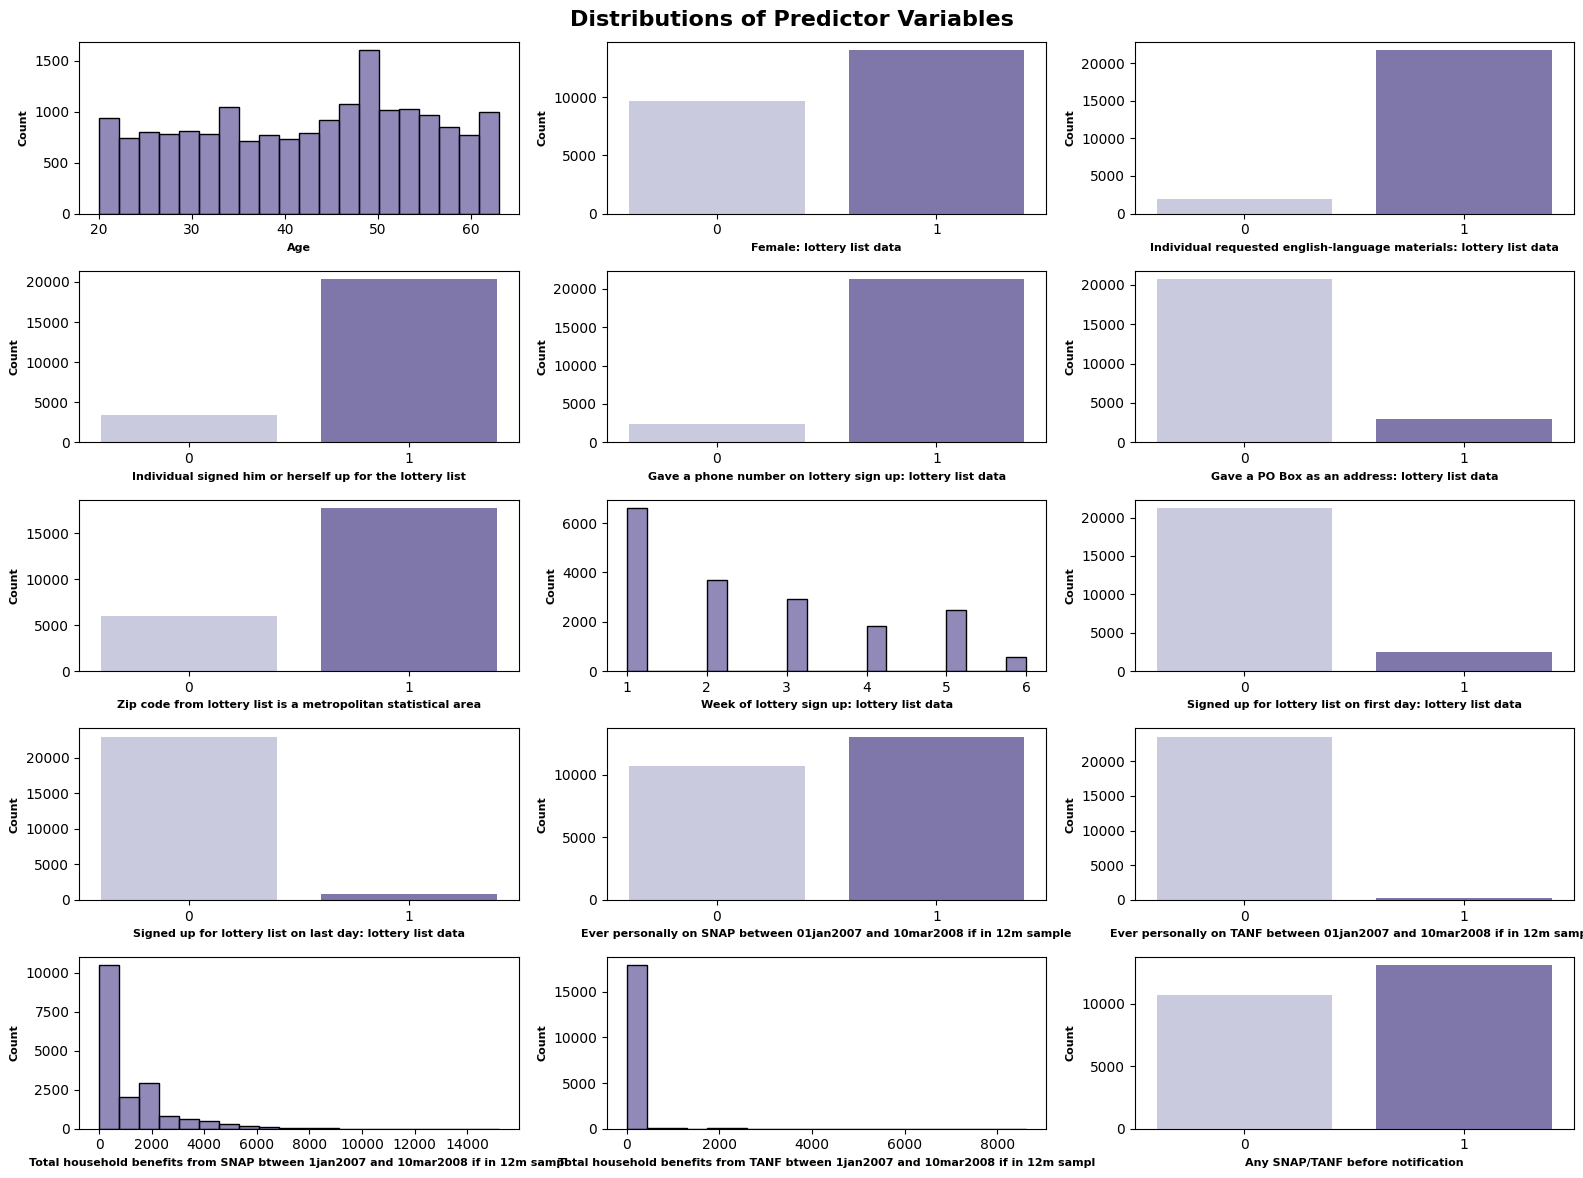

In [35]:
# Lets visualize the distribution of predictor variables in our dataset using histograms (continuous) and bar charts (binary/categorical)
# Instead of printing and displaying each histogram sequentially, lets create a clean grid layout to show it in one view
# Note: To learn if how to format the plots into a grid layout, instead of printing them all sequentially.
  # Claude Fable 5. Based on the response to prompt: "Instead of printing my plots sequentially, I want to display them in rows/columns to be more organized."
# 5 rows, 3 columns
fig, axes = plt.subplots(5, 3, figsize = (16, 12))
distribution_plots(df, predictors, "Predictor", fig, axes)
fig.savefig(f"{OUTPUT}/predictor_distributions.png")

Each panel shows the distribution of a specific predictor variable using a histogram or bar chart, depending on the data type. Immediately, we can see that the cohort is majorty female, with ages spread fairly evenly across age groups. Most respondents reported an english language preferance, individually signing up for the lottery, have a phone number, live in a metro area, were personally on SNAP between Janruary 2007 and March 2008, and signed up for the lottery in the first few weeks. Additionally, we can see that the total household benefits from SNAP or TANF appear to be highly skewed, with most respondents reporting no total household benefits, with a few reporting very high amounts.

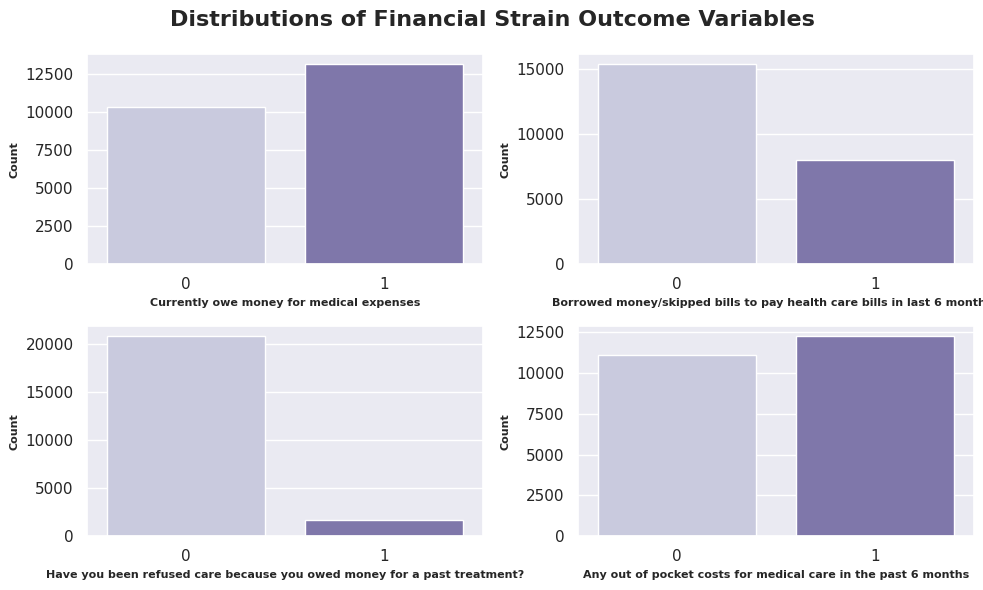

In [36]:
# Lets visualize the distribution of outcome variables in our dataset using bar charts (since they are all binary outcomes)
# Instead of printing and displaying each histogram sequentially, lets create a clean grid layout to show it in one view
# Note: To learn if how to format the plots into a grid layout, instead of printing them all sequentially.
  # Claude Fable 5. Based on the response to prompt: "Instead of printing my plots sequentially, I want to display them in rows/columns to be more organized."
# 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize = (10, 6))
distribution_plots(df, outcomes, "Financial Strain Outcome", fig, axes)
fig.savefig(f"{OUTPUT}/outcome_distributions.png")

Visualizing the distribution of financial strain outcomes, we can see that the majority of participants report owing money for medical expenses. Additionally, we can see that the majority of patients report out of pocket costs for medical care in the past 6 months, with some even needing to borrow money or skipping bills to pay for health care, or being refused care because they owed money for past treatment.

#### 5.5. Outcomes by Treatment Group

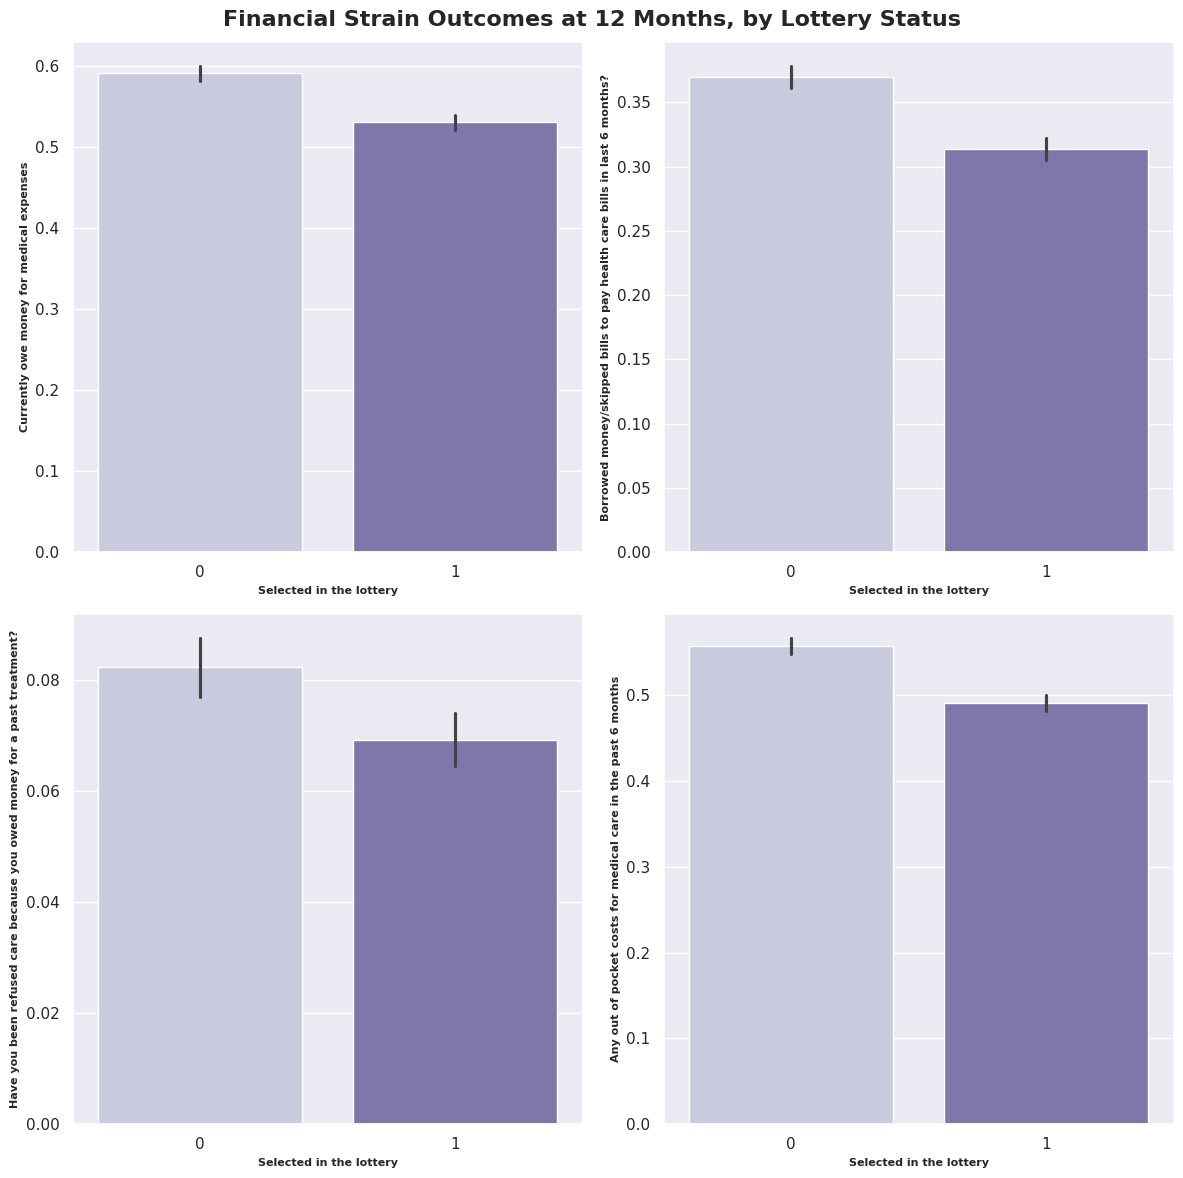

In [37]:
# Instead of printing and displaying each histogram sequentially, lets create a clean grid layout to show it in one view
# 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize = (12, 12))

# Loop through each variable, creating the bar chart for each
for ax, variable in zip(axes.flat, outcomes):
  # Using hue = outcome to group by treatment group, and use ax = ax for the grid layout
  # https://python-graph-gallery.com/barplot/
  sns.barplot(data = df, x = treatment, y = variable, hue = treatment, palette = "Purples", legend = False, ax = ax)
  # Set the x and y labels
  ax.set_xlabel(labels[treatment], fontsize = 8, fontweight = "bold")
  ax.set_ylabel(labels[variable], fontsize = 8, fontweight = "bold")

# Since we are using a grid layout, lets add one clean title that applies to all plots
fig.suptitle("Financial Strain Outcomes at 12 Months, by Lottery Status", fontsize = 16, fontweight = "bold")
sns.set_theme(style = "darkgrid")
# Ensure the grid layout is being applied
fig.tight_layout()
fig.savefig(f"{OUTPUT}/outcome_distributions_by_lottery_status.png")
plt.show()


When visualizing financial strain outcomes by treatment group (i.e., selected in lottery or not selected in lottery), we can immediately see that those in the selected in the lottery have lower rates of financial strain across all four outcome variables (i.e., owe money for medical expenses, borrowed money or skipped bills to pay health care bills, refused care because of medidal debt, and had to pay out of pocket for medical care in the past 6 months).

#### 5.6. Subgroup Analysis

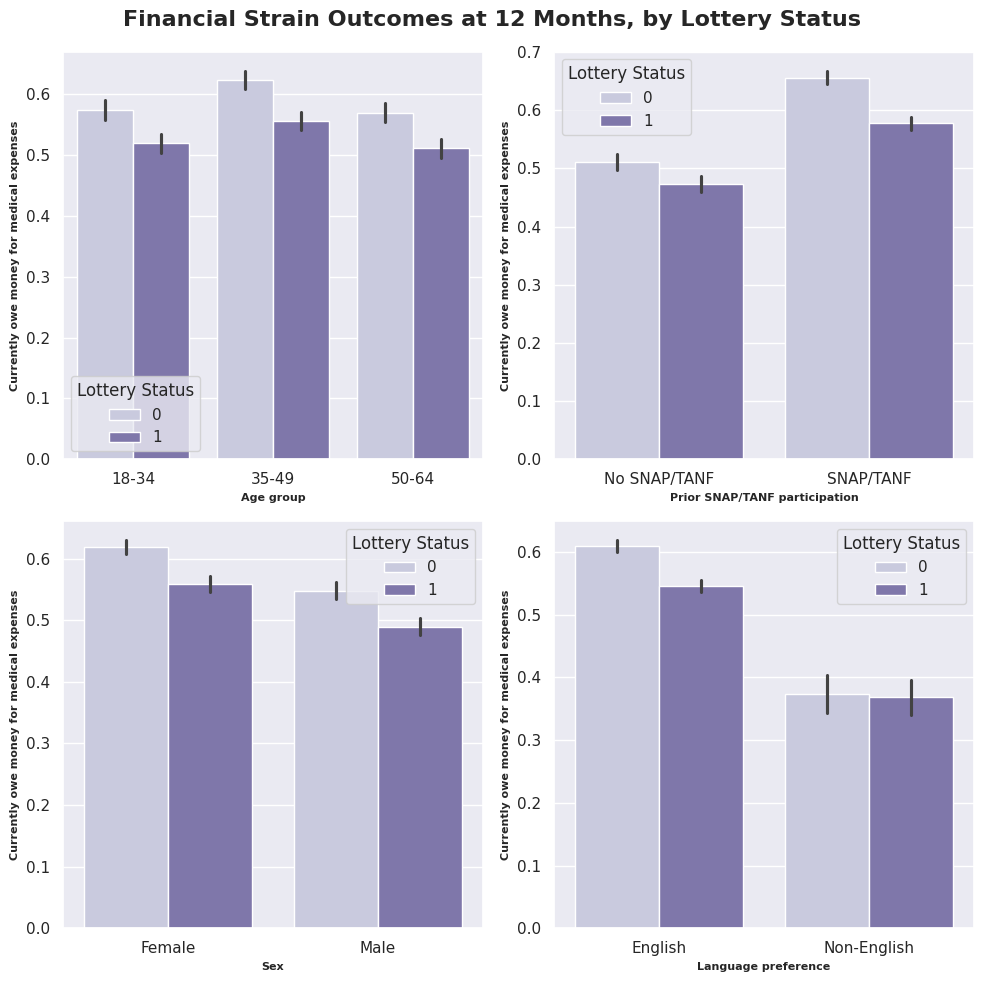

In [38]:
# Instead of printing and displaying each histogram sequentially, lets create a clean grid layout to show it in one view
# 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize = (10, 10))

# Loop through each variable, creating the bar chart for each
for ax, subgroup in zip(axes.flat, subgroups):
  # Using hue = outcome to group by diabetes status, and use ax = ax for the grid layout
  # https://python-graph-gallery.com/barplot/
  sns.barplot(data = df, x = subgroup, y = outcome, hue = treatment, palette = "Purples", ax = ax)
  # Set the x, y, and legend labels
  ax.set_xlabel(labels[subgroup], fontsize = 8, fontweight = "bold")
  ax.set_ylabel(labels[outcome], fontsize = 8, fontweight = "bold")
  legend = ax.get_legend()
  legend.set_title("Lottery Status")

# Since we are using a grid layout, lets add one clean title that applies to all plots
fig.suptitle("Financial Strain Outcomes at 12 Months, by Lottery Status", fontsize = 16, fontweight = "bold")
sns.set_theme(style = "darkgrid")
# Ensure the grid layout is being applied
fig.tight_layout()
fig.savefig(f"{OUTPUT}/outcome_distributions_by_subgroup.png")
plt.show()

Here, we visualized financial strain outcomes by treatment group (i.e., selected in lottery or not selected in lottery) and by subgroup (i.e., age group, prior SNAP/TANF participation, sex, and language preferance). We can see that the direction of difference between treatment groups is consistent across all subgroups (those selected in lottery have lower rates of financial strain), however, the magnitude of that difference does vary. For instance, we can see that there appears to be a larger difference between treatment groups for those with prior SNAP/TANF participation than those with not. Additionally, those with non-english language prefereance appear to have much more consistent rates across treatment groups. It will be important to investigate these differences further with a more robust subgroup analysis once during the full analysis.

#### 5.7. Predictor Correlation Matrix & Heatmap

In [39]:
# Lets create our correlation matrix using .corr(), and rename() to use the readable labels from the predictor dictionary
# Note: To learn how to create a correlation matrix in Python
  # Claude Fable 5. Based on the response to prompt: "How can I make a correlation matrix in Python, how to choose/change the method used, and how to use the values in a dictionary as the labels with the keys as the variables."
# Spearman was chosen over Pearson because snap_dollars_pre and tanf_dollars_pre appear to be right skewed
correlation_matrix = df[predictors].corr(method = "spearman").round(3)
correlation_matrix

,age,female,english,self_signup,has_phone,pobox,metro,signup_week,signup_first_day,signup_last_day,snap_pre,tanf_pre,snap_dollars_pre,tanf_dollars_pre,any_program_pre
age,1.000,-0.023,0.061,0.018,-0.005,0.083,-0.073,-0.050,0.030,-0.017,0.000,-0.058,-0.063,-0.032,-0.001
female,-0.023,1.000,0.007,0.144,0.025,-0.001,-0.002,-0.019,0.005,-0.007,0.017,0.046,0.037,0.058,0.018
english,0.061,0.007,1.000,0.129,-0.030,0.063,-0.078,-0.061,0.052,-0.010,0.196,0.004,0.076,-0.014,0.192
self_signup,0.018,0.144,0.129,1.000,-0.025,-0.001,0.027,0.027,-0.007,0.023,0.081,0.017,0.023,0.012,0.081
has_phone,-0.005,0.025,-0.030,-0.025,1.000,-0.010,0.010,0.041,-0.026,-0.030,0.035,-0.016,0.034,-0.003,0.036
pobox,0.083,-0.001,0.063,-0.001,-0.010,1.000,-0.263,0.034,-0.010,0.014,0.015,-0.013,0.002,-0.004,0.015
metro,-0.073,-0.002,-0.078,0.027,0.010,-0.263,1.000,-0.041,0.033,0.005,-0.034,0.017,-0.024,0.003,-0.034
signup_week,-0.050,-0.019,-0.061,0.027,0.041,0.034,-0.041,1.000,-0.388,0.265,-0.053,-0.001,-0.056,-0.010,-0.053
signup_first_day,0.030,0.005,0.052,-0.007,-0.026,-0.010,0.033,-0.388,1.000,-0.063,0.031,-0.007,0.028,-0.003,0.032
signup_last_day,-0.017,-0.007,-0.010,0.023,-0.030,0.014,0.005,0.265,-0.063,1.000,-0.039,0.000,-0.035,0.002,-0.039


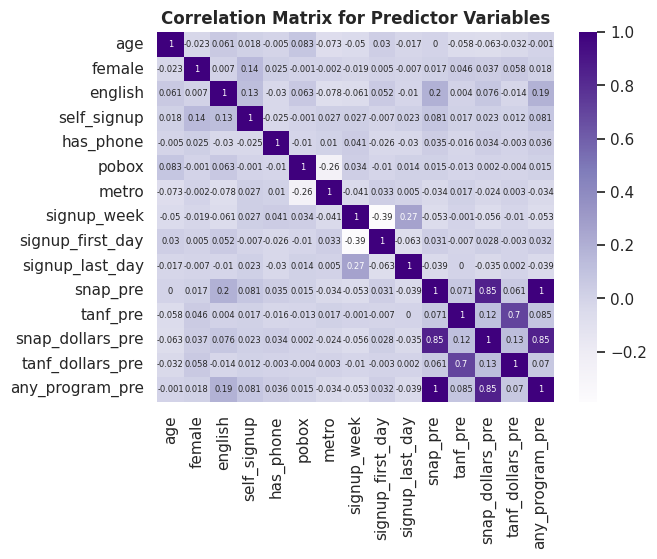

In [40]:
# Create a heatmap to visualize the correlation matrix
# Using annot = True to include the numeric labels
# https://python-graph-gallery.com/91-customize-seaborn-heatmap
sns.heatmap(correlation_matrix, annot = True, annot_kws = {"size": 6}, cmap = "Purples")
plt.title("Correlation Matrix for Predictor Variables", fontsize = 12, fontweight = "bold")
sns.set_theme(style = "darkgrid")
plt.savefig(f"{OUTPUT}/predictor_correlation_heatmap.png")
plt.show()

The matrix and heatmap report the Spearman rank correlations between each pair of predictors. Spearman was chosen for it's more robustness to skewed data and outliers, since household SNAP/TANF benefit amounts appear to be right skewed with clear outliers.

The strongest relationships were mostly by design. Any program participation (SNAP or TANF) was nearly identical to SNAP participation (0.999). Similarly, TANF participation and household TANF benefit amounts were strongly correlated (0.7), and SNAP participation and household SNAP benefit amounts were strongly correlated (0.85). Meanwhile, living in a metro area was moderately negatively correlated with reporting a PO box. With that said, the majority of relationships were only weakly correlated with each other.

### AI Use Statement
---

Generative AI (Claude) was used as a coding, learning, and editing assistant for the following:

- Brainstorming dataset and project ideas, based on my research interests and background, and scoping the study design, such as including a combination of classification, causal inference, and policy simulation components.
- Python syntax and package questions, Colab environment setup (package version installing, file locating and extraction), organizing code into reusable functions, and debgugging code.

I verified and reviewed all work. I take full responsibility for the accuracy and legitimacy of all work submitted.
